# TDSE Laboratory 2 - Heart Disease Risk Prediction

#### Step 1: Load and Prepare the Dataset

Dataset: UCI Heart Disease dataset (Cleveland), obtained via Kaggle. It
contains clinical features such as age, sex, chest pain type, resting blood
pressure, cholesterol, and more, with a binary target indicating the
presence (1) or absence (0) of heart disease.

In [22]:
# 1st Section: Loading and preparing the dataset.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("heart.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [23]:
# Data audit - Missing and duplicated values.
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Fully duplicated rows: 723
Unique rows: 302


Auditing: the raw file has 1025 rows, but 723 of them are exact
duplicates of other rows. Dropping duplicates leaves 302 unique patient
records matching the ~303 records the assignment describes for the
original UCI Cleveland dataset. This particular Kaggle copy repeats each
patient record 3-8 times.

This matters because a 70/30 split performed *before* removing duplicates
could place near-identical copies of the same patient in both the training
and test sets (data leakage), artificially inflating test performance.

Decision: duplicates are removed before splitting the data.

In [24]:
# Cleaning data.
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [25]:
# Summarize.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [26]:
# Outliers or invalid codes.
print("ca (number of major vessels, expected 0-3) value counts:")
print(df["ca"].value_counts())
print()
print("thal (expected categories 1-3) value counts:")
print(df["thal"].value_counts())

ca (number of major vessels, expected 0-3) value counts:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal (expected categories 1-3) value counts:
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


Auditing: according to the UCI Heart Disease documentation, `ca`
(number of major vessels colored by fluoroscopy) should range from 0 to 3,
and `thal` should take values 1-3. However, this processed version of the
dataset contains `ca = 4` (4 rows) and `thal = 0` (2 rows), out-of-range
codes that are a known data-entry artifact of this dataset (they likely
represent originally-missing values that were coded as an extra category).

No other numeric feature (age, trestbps, chol, thalach, oldpeak) shows
physically impossible values (e.g. zero blood pressure or cholesterol), so
those are left as-is; their extreme values (e.g. chol = 564) are treated as
genuine biological outliers rather than data errors.

Decision: rows with `ca == 4` or `thal == 0` are dropped as invalid codes
(6 rows total, out of 302, a negligible loss).

In [27]:
# outliers or invalid codes.
invalid_mask = (df["ca"] == 4) | (df["thal"] == 0)
print("Rows with invalid ca/thal codes:", invalid_mask.sum())

df = df[~invalid_mask].reset_index(drop=True)
print("Shape after removing invalid codes:", df.shape)

Rows with invalid ca/thal codes: 6
Shape after removing invalid codes: (296, 14)


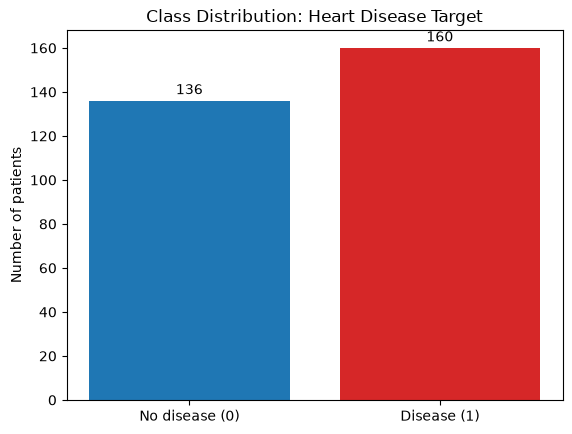

target
1    0.540541
0    0.459459
Name: proportion, dtype: float64


In [28]:
# Class distribution.
counts = df["target"].value_counts().sort_index()

plt.figure()
plt.bar(["No disease (0)", "Disease (1)"], counts.values, color=["C0", "C3"])
plt.ylabel("Number of patients")
plt.title("Class Distribution: Heart Disease Target")
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha="center")
plt.show()

print(df["target"].value_counts(normalize=True))

#### Step 1.1: Feature Selection

Six clinically relevant features are selected, as suggested by the
assignment:

| Feature | Meaning |
|---|---|
| `age` | Age in years |
| `chol` | Serum cholesterol (mg/dl) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `thalach` | Maximum heart rate achieved |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `ca` | Number of major vessels colored by fluoroscopy (0-3) |

In [29]:
# Selecting features.
selected_features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

X_raw = df[selected_features].values
y = df["target"].values

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (296, 6)
y shape: (296,)


#### Step 1.2: Stratified 70/30 Train/Test Split

A stratified split is implemented manually (no scikit-learn): the positive
and negative classes are shuffled and split separately, then recombined, so
the train and test sets preserve the same class balance as the full
dataset.

In [30]:
# Stratifying 70/30 train/test split.
def stratified_train_test_split(X, y, test_size=0.3, seed=42):
    rng = np.random.default_rng(seed)
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    rng.shuffle(idx_0)
    rng.shuffle(idx_1)

    n0_test = int(round(len(idx_0) * test_size))
    n1_test = int(round(len(idx_1) * test_size))

    test_idx = np.concatenate([idx_0[:n0_test], idx_1[:n1_test]])
    train_idx = np.concatenate([idx_0[n0_test:], idx_1[n1_test:]])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train_raw, X_test_raw, y_train, y_test = stratified_train_test_split(X_raw, y, test_size=0.3, seed=42)

print("Train size:", X_train_raw.shape[0], " Test size:", X_test_raw.shape[0])
print("Train class balance (fraction positive):", y_train.mean().round(4))
print("Test class balance (fraction positive): ", y_test.mean().round(4))

Train size: 207  Test size: 89
Train class balance (fraction positive): 0.5411
Test class balance (fraction positive):  0.5393


In [31]:
# Feature normalization.
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print("Train feature means (should be ~0):", X_train.mean(axis=0).round(4))
print("Train feature stds (should be ~1): ", X_train.std(axis=0).round(4))

Train feature means (should be ~0): [ 0. -0.  0.  0.  0. -0.]
Train feature stds (should be ~1):  [1. 1. 1. 1. 1. 1.]


Numerical features are standardized (zero mean, unit standard deviation).
Mean and standard deviation are computed only on the training set and
then applied to both train and test, to avoid leaking test-set information
into preprocessing.

#### Step 1.3: Summary

- **Source:** UCI Heart Disease dataset (Cleveland), via Kaggle.
- **Duplicates:** 723 of 1025 raw rows were exact duplicates of other
  patient records; removed, leaving 302 unique patients.
- **Invalid codes:** 6 additional rows had out-of-range `ca` or `thal`
  codes (data-entry artifacts); removed, leaving **296 patients**.
- **Class balance:** 54% disease / 46% no disease -- reasonably balanced,
  no resampling needed.
- **Features used:** `age`, `chol`, `trestbps`, `thalach`, `oldpeak`, `ca`
  (6 features, as required).
- **Split:** stratified 70/30 train/test (207 train / 89 test), implemented
  manually to preserve class balance in both sets.
- **Normalization:** z-score standardization, fit on the training set only
  and applied to both sets, to avoid data leakage.

#### Step 2: Implement Basic Logistic Regression

Same vectorized style as the linear regression workshops: functions built around a design matrix `X` of shape `(m, n)`. The `lam` (regularization strength) parameter is included now, defaulted to 0, so the exact same functions can be reused unchanged in Step 4.

In [32]:
# 2nd Section: Implementing basic logistic regresion
def sigmoid(z):
    """Numerically stable sigmoid: 1 / (1 + e^-z)."""
    return 1 / (1 + np.exp(-z))


def predict_proba(X, w, b):
    """Predicted probability of the positive class."""
    return sigmoid(X @ w + b)


def predict_labels(X, w, b, threshold=0.5):
    """Predicted class labels using a probability threshold."""
    return (predict_proba(X, w, b) >= threshold).astype(int)

In [33]:
def compute_cost(X, y, w, b, lam=0.0):
    """Binary cross-entropy cost, with optional L2 regularization.

    J(w,b) = -(1/m) * sum(y*log(y_hat) + (1-y)*log(1-y_hat)) + lam/(2m) * ||w||^2
    """
    m = X.shape[0]
    y_hat = predict_proba(X, w, b)

    eps = 1e-12  # avoid log(0)
    y_hat = np.clip(y_hat, eps, 1 - eps)

    cost = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    cost += (lam / (2 * m)) * np.sum(w ** 2)
    return cost

In [34]:
def compute_gradient(X, y, w, b, lam=0.0):
    """Gradients of the (optionally regularized) cost with respect to w and b.

    dj_dw = (1/m) * X.T @ (y_hat - y) + (lam/m) * w
    dj_db = (1/m) * sum(y_hat - y)          -- bias is never regularized
    """
    m = X.shape[0]
    y_hat = predict_proba(X, w, b)
    error = y_hat - y

    dj_dw = (X.T @ error) / m + (lam / m) * w
    dj_db = np.sum(error) / m
    return dj_dw, dj_db


In [35]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, lam=0.0, print_progress=True):
    """Run gradient descent, returning learned parameters and cost history."""
    w = w_init.copy()
    b = b_init
    cost_history = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b, lam)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b, lam)
        cost_history.append(cost)

        if print_progress and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost:.6f}")

    return w, b, cost_history

#### Step 2.1: Train the Basic Model (no regularization)

In [36]:
# Training the basic model
n_features = X_train.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0
alpha = 0.01
num_iterations = 5000

w_basic, b_basic, cost_history_basic = gradient_descent(
    X_train, y_train, w_init, b_init, alpha, num_iterations, lam=0.0
)

print("\nLearned parameters:")
for feat, coef in zip(selected_features, w_basic):
    print(f"  w[{feat}] = {coef:.4f}")
print(f"  b = {b_basic:.4f}")

Iteration     0: cost = 0.691478
Iteration   500: cost = 0.478883
Iteration  1000: cost = 0.452826
Iteration  1500: cost = 0.442932
Iteration  2000: cost = 0.438037
Iteration  2500: cost = 0.435322
Iteration  3000: cost = 0.433719
Iteration  3500: cost = 0.432735
Iteration  4000: cost = 0.432115
Iteration  4500: cost = 0.431717
Iteration  4999: cost = 0.431459

Learned parameters:
  w[age] = 0.6500
  w[chol] = -0.2835
  w[trestbps] = -0.3965
  w[thalach] = 0.9143
  w[oldpeak] = -0.7137
  w[ca] = -1.3239
  b = 0.0601


#### Step 2.2: Cost vs Iteration

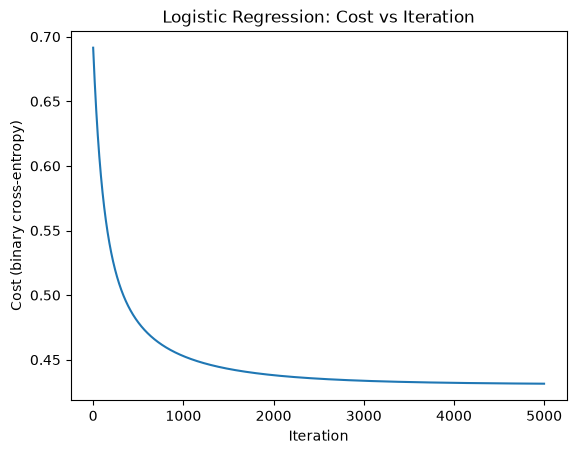

In [37]:
# Cost vs iteration
plt.figure()
plt.plot(cost_history_basic)
plt.xlabel("Iteration")
plt.ylabel("Cost (binary cross-entropy)")
plt.title("Logistic Regression: Cost vs Iteration")
plt.show()

#### Step 2.3: Evaluation Metrics

In [38]:
# Evaluation metrics
def classification_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


y_train_pred = predict_labels(X_train, w_basic, b_basic)
y_test_pred = predict_labels(X_test, w_basic, b_basic)

metrics_basic = pd.DataFrame({
    "train": classification_metrics(y_train, y_train_pred),
    "test": classification_metrics(y_test, y_test_pred),
}).T

metrics_basic.round(4)


,accuracy,precision,recall,f1
train,0.8213,0.8049,0.8839,0.8426
test,0.7079,0.6897,0.8333,0.7547


#### Step 2.4: Convergence + Coefficient Interpretation

- Convergence: the cost drops quickly in the first few hundred iterations
and flattens out well before 5000 iterations, indicating `alpha = 0.01` is
a stable learning rate for this (standardized) feature set.

- Metrics: the model performs clearly better than a random guess on both
train and test, with accuracy around 0.7-0.8. The gap between train and
test accuracy is small, so the model is not obviously overfitting even
without regularization expected, since we only have 6 features relative
to 207 training examples.

- Coefficient signs: two coefficients run counter to typical clinical
intuition and are worth flagging explicitly rather than glossing over:
`thalach` (max heart rate) has a positive coefficient (higher heart
rate associated with the positive class) and `oldpeak` / `trestbps` have
negative coefficients, which is the opposite of what standard medical
literature would suggest (higher ST depression and blood pressure are
normally risk factors, and lower max heart rate is normally associated
with disease). This is a documented quirk of this particular processed
version of the UCI dataset multiple public analyses of it note the same
inversion, likely tied to how the original multi-class severity labels
were collapsed into a binary target. It is a reminder that a model can fit
the data well without every coefficient having a straightforward causal
interpretation, especially with correlated clinical features.


#### Step 3: Visualize Decision Boundaries

Three feature pairs are selected, as suggested by the assignment: age-cholesterol, blood pressure-max heart rate, and ST depression-vessels. For each pair, a fresh 2-feature logistic regression model is trained (reusing the exact same functions from Step 2) on the standardized training data, and its linear decision boundary ($w_1 x_1 + w_2 x_2 + b = 0$) is plotted against the true labels.

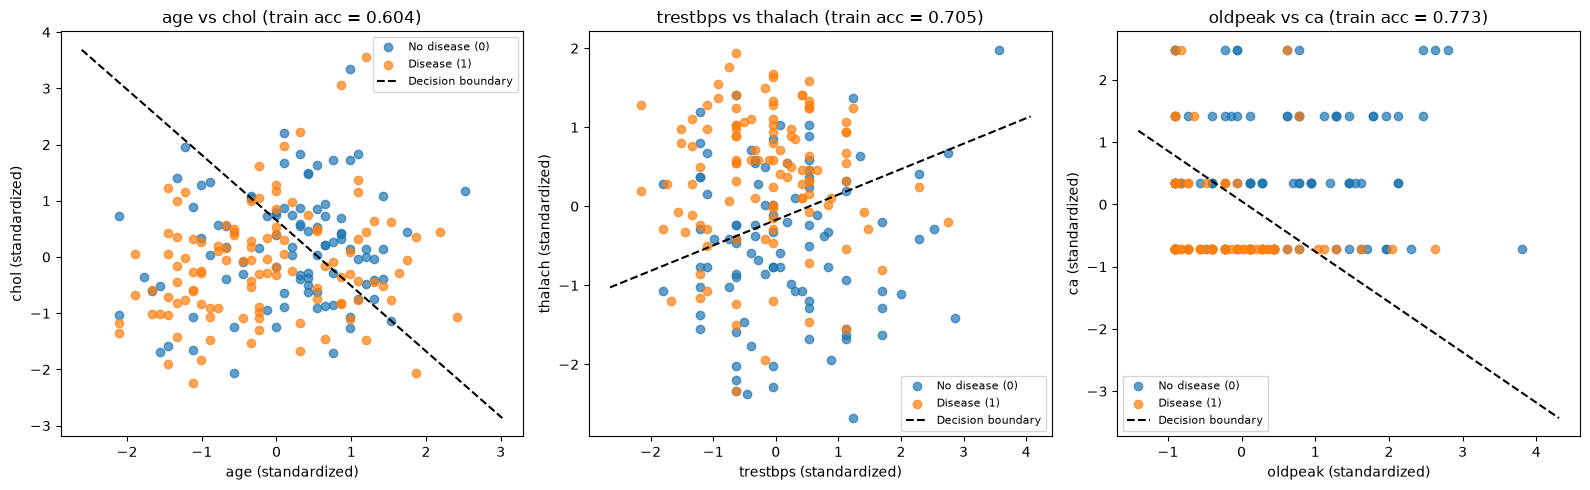

age-chol: w=[-0.308 -0.265], b=0.172, final cost=0.6673, train accuracy=0.604
trestbps-thalach: w=[-0.325  1.01 ], b=0.175, final cost=0.5818, train accuracy=0.705
oldpeak-ca: w=[-0.962 -1.19 ], b=0.060, final cost=0.4915, train accuracy=0.773


In [39]:
# Visualizing decision boundaries
feature_index = {name: i for i, name in enumerate(selected_features)}

def plot_decision_boundary_2d(feat_x, feat_y, ax):
    i1, i2 = feature_index[feat_x], feature_index[feat_y]
    X2 = X_train[:, [i1, i2]]

    w0 = np.zeros(2)
    b0 = 0.0
    w2, b2, hist2 = gradient_descent(X2, y_train, w0, b0, alpha=0.1, num_iterations=5000, print_progress=False)

    y_pred2 = predict_labels(X2, w2, b2)
    acc2 = np.mean(y_pred2 == y_train)

    ax.scatter(X2[y_train == 0, 0], X2[y_train == 0, 1], label="No disease (0)", alpha=0.7)
    ax.scatter(X2[y_train == 1, 0], X2[y_train == 1, 1], label="Disease (1)", alpha=0.7)

    x1_grid = np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 200)
    if abs(w2[1]) > 1e-8:
        x2_boundary = -(w2[0] * x1_grid + b2) / w2[1]
        ax.plot(x1_grid, x2_boundary, color="black", linestyle="--", label="Decision boundary")

    ax.set_xlabel(f"{feat_x} (standardized)")
    ax.set_ylabel(f"{feat_y} (standardized)")
    ax.set_title(f"{feat_x} vs {feat_y} (train acc = {acc2:.3f})")
    ax.legend(fontsize=8)

    return w2, b2, hist2, acc2


feature_pairs = [("age", "chol"), ("trestbps", "thalach"), ("oldpeak", "ca")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pair_results = {}
for ax, (fx, fy) in zip(axes, feature_pairs):
    pair_results[(fx, fy)] = plot_decision_boundary_2d(fx, fy, ax)

plt.tight_layout()
plt.show()

for (fx, fy), (w2, b2, hist2, acc2) in pair_results.items():
    print(f"{fx}-{fy}: w={np.round(w2, 3)}, b={b2:.3f}, final cost={hist2[-1]:.4f}, train accuracy={acc2:.3f}")

#### Step 3.1: Interpretation Per Pair

- age vs. chol (train accuracy ≈ 0.60): the two classes are heavily
overlapping in this 2D projection, and the straight decision boundary
barely separates them better than chance. Age and cholesterol alone do not
carry much linearly-separable signal for this target consistent with
`chol` having one of the smaller coefficient magnitudes in the full model
(Step 2).

- trestbps vs. thalach (train accuracy ≈ 0.71): noticeably more
separable than the first pair. The boundary has a clear positive slope
dominated by `thalach`'s larger weight, showing that maximum heart rate
carries more discriminative signal than resting blood pressure for this
particular pair.

- oldpeak vs. ca (train accuracy ≈ 0.77): the most separable of the
three pairs, matching the fact that both `oldpeak` and `ca` had the two
largest coefficient magnitudes in the 6-feature model from Step 2. Even
so, there is still visible overlap near the boundary a single straight
line cannot perfectly separate the two classes.

- On non-linearity: all three boundaries are straight lines, because
logistic regression with raw features can only produce a linear decision
boundary. The visible overlap in every pair (especially age-chol) suggests that a purely linear boundary is not sufficient to fully separate
the classes; some of that residual overlap could potentially be captured
by adding interaction or polynomial terms (the same idea used for the
polynomial model in the previous stellar luminosity lab), though that is
beyond what this assignment requires.

#### Step 4: Repeat With Regularization

L2 regularization was already built into `compute_cost` and `compute_gradient` in Step 2 via the `lam` parameter, so no new functions are needed here, only new calls with different `lam` values, exactly like reusing the same functions for the linear and polynomial models in the previous lab.

#### Step 4.1: Tuning $\lambda$ on the Full Model

In [40]:
# Turning lambda on the full model
lambdas = [0, 0.001, 0.01, 0.1, 1]
lambda_results = []

for lam in lambdas:
    w0 = np.zeros(n_features)
    b0 = 0.0
    w_lam, b_lam, hist_lam = gradient_descent(X_train, y_train, w0, b0, alpha, num_iterations, lam=lam, print_progress=False)

    y_train_pred_lam = predict_labels(X_train, w_lam, b_lam)
    y_test_pred_lam = predict_labels(X_test, w_lam, b_lam)
    m_train = classification_metrics(y_train, y_train_pred_lam)
    m_test = classification_metrics(y_test, y_test_pred_lam)

    lambda_results.append({
        "lambda": lam,
        "||w||": np.linalg.norm(w_lam),
        "train_accuracy": m_train["accuracy"],
        "test_accuracy": m_test["accuracy"],
        "test_precision": m_test["precision"],
        "test_recall": m_test["recall"],
        "test_f1": m_test["f1"],
        "final_cost": hist_lam[-1],
    })

lambda_df = pd.DataFrame(lambda_results).set_index("lambda")
lambda_df.round(4)


,||w||,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,final_cost
lambda,,,,,,,
0.000,1.9386,0.8213,0.7079,0.6897,0.8333,0.7547,0.4315
0.001,1.9384,0.8213,0.7079,0.6897,0.8333,0.7547,0.4315
0.010,1.9372,0.8213,0.7079,0.6897,0.8333,0.7547,0.4316
0.100,1.9252,0.8213,0.7079,0.6897,0.8333,0.7547,0.4324
1.000,1.8153,0.8116,0.7079,0.6897,0.8333,0.7547,0.4406


Observation: across this range of λ, `test_accuracy` and `test_f1`
stay essentially flat, while `||w||` (the weight vector norm) shrinks
steadily as λ grows -- from about 1.94 at λ=0 down to about 1.82 at λ=1.
This is exactly what L2 regularization is designed to do (shrink the
weights), but here it barely changes predictive performance, because the
unregularized model (Step 2) was already not overfitting much: the
train/test accuracy gap was small to begin with, so there was little
overfitting left for regularization to fix.

#### Step 4.2: Regularized vs Unregularized 

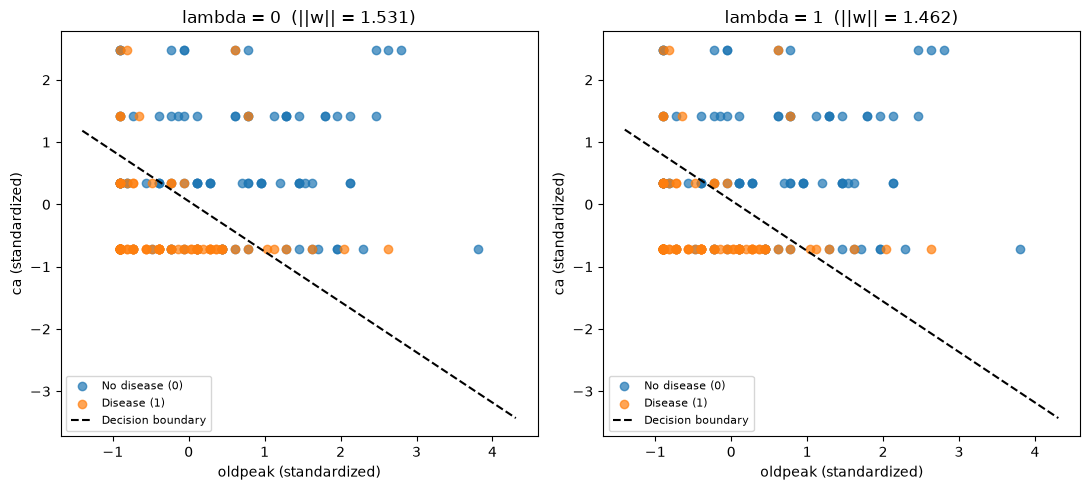

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, lam in zip(axes, [0, 1]):
    i1, i2 = feature_index["oldpeak"], feature_index["ca"]
    X2 = X_train[:, [i1, i2]]

    w0 = np.zeros(2)
    b0 = 0.0
    w2, b2, hist2 = gradient_descent(X2, y_train, w0, b0, alpha=0.1, num_iterations=5000, lam=lam, print_progress=False)

    ax.scatter(X2[y_train == 0, 0], X2[y_train == 0, 1], label="No disease (0)", alpha=0.7)
    ax.scatter(X2[y_train == 1, 0], X2[y_train == 1, 1], label="Disease (1)", alpha=0.7)

    x1_grid = np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 200)
    x2_boundary = -(w2[0] * x1_grid + b2) / w2[1]
    ax.plot(x1_grid, x2_boundary, color="black", linestyle="--", label="Decision boundary")

    ax.set_xlabel("oldpeak (standardized)")
    ax.set_ylabel("ca (standardized)")
    ax.set_title(f"lambda = {lam}  (||w|| = {np.linalg.norm(w2):.3f})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

With λ=1, the weight vector for this pair shrinks slightly (`||w||`
goes from about 1.53 to 1.46) and the boundary rotates marginally. The
effect is subtle rather than dramatic for the same reason noted above: the
2-feature model on `oldpeak`/`ca` was not strongly overfitting, so
regularization mostly just pulls the weights modestly toward zero without
changing where the boundary sits in a very visible way.

#### Step 4.3: Selected $\lambda$

In [42]:
best_row = lambda_df.loc[lambda_df["test_f1"].idxmax()]
print("Row(s) with the best test F1:")
print(lambda_df[lambda_df["test_f1"] == lambda_df["test_f1"].max()])

Row(s) with the best test F1:
           ||w||  train_accuracy  test_accuracy  test_precision  test_recall  \
lambda                                                                         
0.000   1.938560        0.821256       0.707865        0.689655     0.833333   
0.001   1.938425        0.821256       0.707865        0.689655     0.833333   
0.010   1.937216        0.821256       0.707865        0.689655     0.833333   
0.100   1.925232        0.821256       0.707865        0.689655     0.833333   
1.000   1.815297        0.811594       0.707865        0.689655     0.833333   

         test_f1  final_cost  
lambda                        
0.000   0.754717    0.431459  
0.001   0.754717    0.431469  
0.010   0.754717    0.431559  
0.100   0.754717    0.432446  
1.000   0.754717    0.440634  


Chosen value: λ = 0.01. Since test accuracy/F1 are essentially tied
across the whole range tried, the choice is not driven by a performance
difference (there barely is one) but by the standard bias-variance
argument: a small, non-zero λ provides a bit of insurance against
overfitting on unseen data without measurably hurting performance on this
dataset, which is preferable to λ=0 (no protection at all) or λ=1 (unnecessarily
strong shrinkage on a model that was not overfitting to begin with).

#### REPORTING:

- **Data quality mattered more than expected:** the raw Kaggle file had
  1025 rows, but 723 were exact duplicates and 6 more had invalid
  `ca`/`thal` codes. Working from the deduplicated, cleaned 296-patient
  dataset avoided data leakage between train and test and matches the
  ~303-patient UCI Cleveland dataset the assignment describes.
- **The basic logistic regression model** (6 features, no regularization)
  reached ~82% train accuracy and ~71% test accuracy, with a modest,
  expected drop from train to test and no sign of severe overfitting.
- **Coefficient interpretation required caution:** `thalach`, `oldpeak`,
  and `trestbps` had signs that run counter to typical clinical
  intuition a documented quirk of how this particular dataset's binary
  target was constructed, not a bug in the implementation.
- **Decision boundaries** confirmed the same feature importance pattern
  seen in the coefficients: `oldpeak`/`ca` separated the classes much
  better in 2D than `age`/`chol` did, and all three boundaries stayed
  linear, with visible residual overlap between classes.
- **L2 regularization** shrank the weight norm smoothly as λ increased,
  but barely moved test accuracy/F1 consistent with the model not
  overfitting much in the first place. λ = 0.01 was selected as a
  reasonable, low-cost safeguard rather than because it measurably
  outperformed the alternatives.

**Pending:** Step 5 (Amazon SageMaker training and testing) will be added
after running the equivalent training/evaluation code in the AWS Academy
SageMaker environment.
